# Rank by Qualified Score: budget 38% (2026-10-04)

Applicants are ranked by our **qualified score**, not by a model's probabilities. The score is 3 x R score + 0.5 x income need + 0.5 x hours burden (lower income = more need, more hours = more burden). Everything else is the same as the main notebook. There is no model to train, so the hyperparameter search is gone.

Fairness is measured between two groups: **Centre** (Montreal, Capitale-Nationale) vs **Remote** (Bas-Saint-Laurent, Cote-Nord, Gaspesie-Iles-de-la-Madeleine).

## Overview

```
10,000 labeled rows
        ↓
Split:
8,000 train
2,000 validation
        ↓
QUALIFIED SCORE (no model, nothing to train):
score = ( W_R x R + W_INCOME x (1 - income) + W_HOURS x hours ) / sum of weights
columns min-max scaled with the 10,000 rows
        ↓
Score the 2,000 validation rows
        ↓
ON THE 2,000:

FAIRNESS SWEEP

tol = 0.00
tol = 0.02
tol = 0.05
tol = 0.10
tol = 0.20

For EACH tol:
        ↓
ThresholdOptimizer
Demographic Parity
Centre vs Remote
        ↓
Get fairness-adjusted score / selection probability
        ↓
ENFORCE BUDGET:
rank using that fair score
        ↓
TOP 38% = 1
BOTTOM 62% = 0
        ↓
Now measure FINAL:
• accuracy vs committee
• demographic-parity gap (Centre vs Remote)
• grant rate = exactly 38%
        ↓
Each tol = one Pareto point
        ↓
Plot:
x = fairness gap (Centre vs Remote)
y = accuracy
        ↓
Choose best tol
        ↓
Final configuration fixed:
• ranking rule (the formula and its weights)
• tol
        ↓
Apply configuration to 4,000
        ↓
Score the 4,000 with the formula
        ↓
Fairness adjustment
using chosen tol
        ↓
Rank by fair score
        ↓
TOP 1,520 = 1
BOTTOM 2,480 = 0
        ↓
predictions.csv
        ↓
SUBMIT
```

## 1. 10,000 labeled rows: split into 8,000 train and 2,000 validation

The split is stratified on the label and the Centre/Remote group together.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fairlearn.metrics import demographic_parity_difference
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split

# Columns used by the quality formula (these are not model inputs, there is no model)
FORMULA_COLS = ["cote_r_equivalent", "revenu_familial_estime", "heures_travail_semaine"]
# Weights of the qualified score: 3 x R + 0.5 x income need + 0.5 x hours burden
W_R, W_INCOME, W_HOURS = 3.0, 0.5, 0.5
TOL_VALUES = [0.0, 0.02, 0.05, 0.10, 0.20]   # 0.0 = strictest (no relaxation)
BUDGET, SEED = 0.38, 42
REMOTE = {"Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine"}

# Data is in equialgo-participants/data. Walk up from this notebook until it is found.
data_dir = next(
    (p / "equialgo-participants" / "data" for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "equialgo-participants" / "data" / "donnees_demandes.csv").is_file()),
    None,
)
if data_dir is None:
    raise FileNotFoundError("Could not find equialgo-participants/data from " + str(Path.cwd()))
OUT_DIR = Path.cwd()   # outputs are saved next to this notebook, inside its feature_set folder
print("Reading data from:", data_dir)
print("Saving outputs to:", OUT_DIR)
STEM = f"rank_by_qualified_score_budget_{round(BUDGET * 100)}pct"   # same name as the notebook

df = pd.read_csv(data_dir / "donnees_demandes.csv")
cols = FORMULA_COLS
X, y = df[cols], df["decision_octroi"]
g = pd.Series(np.where(df["region_administrative"].isin(REMOTE), "Remote", "Centre"), index=df.index)

# Stratify on label AND region group, so both distributions are preserved in each split
strata = y.astype(str) + "_" + g
X_tr, X_val, y_tr, y_val, g_tr, g_val = train_test_split(
    X, y, g, test_size=0.20, random_state=SEED, stratify=strata
)
print(len(X_tr), "train rows,", len(X_val), "validation rows, formula columns:", cols)
print(pd.DataFrame({
    "all": [y.mean(), (g == "Centre").mean(), (g == "Remote").mean()],
    "train": [y_tr.mean(), (g_tr == "Centre").mean(), (g_tr == "Remote").mean()],
    "validation": [y_val.mean(), (g_val == "Centre").mean(), (g_val == "Remote").mean()],
}, index=["grant rate", "Centre share", "Remote share"]).round(4))

Reading data from: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/equialgo-participants/data
Saving outputs to: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/models/logistic_regression/rank_by_qualified
8000 train rows, 2000 validation rows, formula columns: ['cote_r_equivalent', 'revenu_familial_estime', 'heures_travail_semaine']
                 all   train  validation
grant rate    0.3994  0.3995       0.399
Centre share  0.6000  0.6000       0.600
Remote share  0.4000  0.4000       0.400


## 2. Qualified score: 3R + 0.5 x income need + 0.5 x hours burden (no model)

Each column is scaled to 0 to 1 using the 10,000 rows, and the same scale is reused for the 4,000. Lower income counts as more need, more hours worked counts as more burden. The score is the weighted average.

In [2]:
lo, hi = df[cols].min(), df[cols].max()   # scaling taken from the 10,000 rows, reused for the 4,000


def minmax(frame, col):
    return (frame[col] - lo[col]) / (hi[col] - lo[col])


def quality_score(frame):
    merit = minmax(frame, "cote_r_equivalent")                # higher R score = better
    need = 1 - minmax(frame, "revenu_familial_estime")        # lower income = more need
    burden = minmax(frame, "heures_travail_semaine")          # more hours = more burden
    score = (W_R * merit + W_INCOME * need + W_HOURS * burden) / (W_R + W_INCOME + W_HOURS)
    return score.clip(0, 1).astype("float64").to_numpy()


s_val = quality_score(X_val)   # quality score for each of the 2,000
print("Quality scores on the 2,000:", s_val.shape, "range", s_val.min().round(3), "to", s_val.max().round(3))

Quality scores on the 2,000: (2000,) range 0.146 to 0.874


## 3. On the 2,000: fairness sweep

One pass per value in `TOL_VALUES` (0.00, 0.02, 0.05, 0.10, 0.20). The steps for each `tol` are in sections 4 to 6.

In [3]:
print("Sweep over tol =", TOL_VALUES)

Sweep over tol = [0.0, 0.02, 0.05, 0.1, 0.2]


## 4. For each tol: ThresholdOptimizer (demographic parity, Centre vs Remote)

`ThresholdOptimizer` is fitted on the 2,000 validation rows. It works on the frozen model's scores (a pass-through estimator), and returns the fairness-adjusted score (selection probability).

In [4]:
class ScoreEstimator(BaseEstimator, ClassifierMixin):
    """Treats the frozen model's score as the probability, so ThresholdOptimizer works on scores."""
    def fit(self, X=None, y=None):
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        s = np.asarray(X, dtype="float64").reshape(-1)
        return np.c_[1 - s, s]


def fit_fairness(tol):
    to = ThresholdOptimizer(
        estimator=ScoreEstimator().fit(), constraints="demographic_parity",
        objective="accuracy_score", prefit=True, predict_method="predict_proba",
        tol=None if tol == 0 else tol,
    )
    return to.fit(s_val.reshape(-1, 1), y_val, sensitive_features=g_val)


def fair_score(to, scores, groups):
    """Fairness-adjusted selection probability for each applicant."""
    return to._pmf_predict(scores.reshape(-1, 1), sensitive_features=groups)[:, 1]

## 5. Enforce budget: rank by the fair score, top 38% = 1, bottom 62% = 0

Ties in the fair score are broken by the base model score.

In [5]:
def cut_budget(fair, base_score):
    k = int(BUDGET * len(fair))
    order = np.lexsort((-base_score, -fair))
    out = np.zeros(len(fair), dtype=int)
    out[order[:k]] = 1
    return out

## 6. Measure final: accuracy vs committee, demographic-parity gap (Centre vs Remote), grant rate

The first row is the plain top 38% with no fairness step, for reference.

In [6]:
def measure(pred):
    return {"parity_gap": demographic_parity_difference(y_val, pred, sensitive_features=g_val),
            "accuracy": (pred == y_val).mean(), "grant_rate": pred.mean()}


rows = [{"tol": "plain 38%", **measure(cut_budget(s_val, s_val))}]
for tol in TOL_VALUES:
    to = fit_fairness(tol)
    pred = cut_budget(fair_score(to, s_val, g_val), s_val)
    rows.append({"tol": tol, **measure(pred)})

results = pd.DataFrame(rows)
print(results.round(4).to_string(index=False))
results.round(4).to_csv(OUT_DIR / f"{STEM}_pareto.csv", index=False)

if results["parity_gap"].iloc[1:].round(4).eq(results["parity_gap"].iloc[0].round(4)).all():
    print("\nNOTE: every tol gives the same gap as the plain 38% row. "
          "The budget cut is cancelling the fairness step.")

      tol  parity_gap  accuracy  grant_rate
plain 38%      0.0292     0.825        0.38
      0.0      0.0104     0.829        0.38
     0.02      0.0104     0.829        0.38
     0.05      0.0104     0.829        0.38
      0.1      0.0854     0.845        0.38
      0.2      0.1979     0.856        0.38


## 7. Each tol = one Pareto point

x = fairness gap between Centre and Remote (smaller is fairer), y = accuracy vs committee.

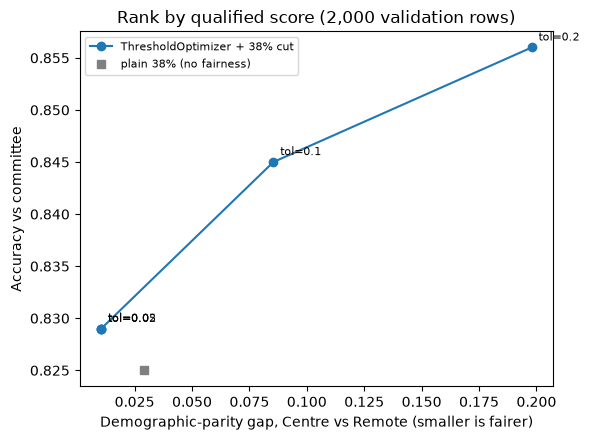

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sweep = results.iloc[1:]
ax.plot(sweep["parity_gap"], sweep["accuracy"], "o-", label="ThresholdOptimizer + 38% cut")
for _, r in sweep.iterrows():
    ax.annotate(f"tol={r['tol']}", (r["parity_gap"], r["accuracy"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.plot(results["parity_gap"].iloc[0], results["accuracy"].iloc[0], "s", color="gray",
        label="plain 38% (no fairness)")
ax.set_xlabel("Demographic-parity gap, Centre vs Remote (smaller is fairer)")
ax.set_ylabel("Accuracy vs committee")
ax.set_title("Rank by qualified score (2,000 validation rows)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / f"{STEM}_pareto.png", dpi=150)
plt.show()

## 8. Choose the best tol

Pick one `tol` from the plot. Prefer a point where the gap has dropped a lot before accuracy falls fast.

In [12]:
CHOSEN_TOL = 0.01   # set to the tol you picked, for example 0.05

## 9. Final configuration fixed

Ranking rule (the formula and its weights) and tol.

In [13]:
final_config = {
    "ranking": "quality formula (no model)",
    "columns": cols,
    "weights": {"R": W_R, "income": W_INCOME, "hours": W_HOURS},
    "budget": BUDGET,
    "tol": CHOSEN_TOL,
}
final_config

{'ranking': 'quality formula (no model)',
 'columns': ['cote_r_equivalent',
  'revenu_familial_estime',
  'heures_travail_semaine'],
 'weights': {'R': 3.0, 'income': 0.5, 'hours': 0.5},
 'budget': 0.38,
 'tol': 0.01}

## 10. Apply the configuration to the 4,000

Fairness adjustment with the chosen `tol`, rank by the fair score, top 1,520 = 1, bottom 2,480 = 0. It also prints the Centre vs Remote gap on the 4,000 themselves, which needs no labels.

In [14]:
if CHOSEN_TOL is None:
    print("Set CHOSEN_TOL in section 8 first.")
else:
    cand = pd.read_csv(data_dir / "candidats_evaluation.csv")
    g_cand = pd.Series(np.where(cand["region_administrative"].isin(REMOTE), "Remote", "Centre"),
                       index=cand.index)
    s_cand = quality_score(cand)
    to = fit_fairness(CHOSEN_TOL)
    pred_cand = cut_budget(fair_score(to, s_cand, g_cand), s_cand)
    print("Ones:", pred_cand.sum(), "of", len(pred_cand))

    # Gap measured on the 4,000 themselves (needs no labels, only the region)
    rates = pd.Series(pred_cand).groupby(g_cand.values).mean()
    print(rates.round(4).to_string())
    print("Gap on the 4,000 (Centre vs Remote):", round(rates["Centre"] - rates["Remote"], 4))

Ones: 1520 of 4000
Centre    0.3676
Remote    0.3980
Gap on the 4,000 (Centre vs Remote): -0.0304


## 11. predictions.csv, then submit

Format: two columns, `id_candidat,decision_octroi`, one row per applicant, ids unchanged. Checks: 4,000 rows, only 0 and 1, exactly 1,520 ones. The file is saved next to this notebook, inside the model folder. Copy it to the repo root as `predictions.csv` to submit.

In [15]:
if CHOSEN_TOL is not None:
    out = pd.DataFrame({"id_candidat": cand["id_candidat"], "decision_octroi": pred_cand})
    assert list(out.columns) == ["id_candidat", "decision_octroi"]
    assert out["id_candidat"].equals(cand["id_candidat"])          # ids unchanged, same order
    assert len(out) == 4000 and set(out["decision_octroi"]) <= {0, 1}
    assert out["decision_octroi"].sum() == int(BUDGET * 4000)
    path = OUT_DIR / f"{STEM}_predictions.csv"
    out.to_csv(path, index=False)
    print(f"Wrote {path}: {len(out)} rows, grant rate {out['decision_octroi'].mean():.2f}")
    print(path.read_text().splitlines()[:4])

Wrote /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/models/logistic_regression/rank_by_qualified/rank_by_qualified_score_budget_38pct_predictions.csv: 4000 rows, grant rate 0.38
['id_candidat,decision_octroi', 'C011476,0', 'C000471,0', 'C006911,0']
